# VAE 在双月牙数据上的训练与生成（对应书中 §12.1）

$$\mathcal{L}=\mathbb{E}_{q_\phi(z|x)}\big[\|x-\mu_\theta(z)\|^2/(2\sigma^2)\big]
+D_{\mathrm{KL}}\big(q_\phi(z|x)\,\|\,\mathcal{N}(0,I)\big)$$

In [1]:
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

def sample_moons(n):
    n1, n2 = n // 2, n - n // 2
    t1 = torch.rand(n1) * math.pi
    t2 = torch.rand(n2) * math.pi
    x1 = torch.stack([torch.cos(t1), torch.sin(t1)], dim=1)
    x2 = torch.stack([1 - torch.cos(t2), -torch.sin(t2) + 0.5], dim=1)
    x = torch.cat([x1, x2]) + 0.05 * torch.randn(n, 2)
    return (x - x.mean(0)) / x.std(0)

data = sample_moons(4096)

In [2]:
latent = 2

encoder = nn.Sequential(nn.Linear(2, 128), nn.SiLU(), nn.Linear(128, 128), nn.SiLU(), nn.Linear(128, 2 * latent))
decoder = nn.Sequential(nn.Linear(latent, 128), nn.SiLU(), nn.Linear(128, 128), nn.SiLU(), nn.Linear(128, 2))

opt = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=1e-3)
sigma2 = 0.01

for epoch in range(5001):
    x = data[torch.randint(0, len(data), (256,))]
    mu, logvar = encoder(x).chunk(2, dim=1)
    z = mu + (0.5 * logvar).exp() * torch.randn_like(mu)
    xr = decoder(z)
    rec = ((x - xr) ** 2).sum(1).mean() / (2 * sigma2)
    kl = 0.5 * (mu ** 2 + logvar.exp() - 1 - logvar).sum(1).mean()
    loss = rec + kl
    opt.zero_grad()
    loss.backward()
    opt.step()
    if epoch % 1000 == 0:
        print(f"epoch {epoch:5d}   rec = {rec.item():8.3f}   kl = {kl.item():6.3f}")

epoch     0   rec =  102.332   kl =  0.025


epoch  1000   rec =    1.182   kl =  4.144


epoch  2000   rec =    1.036   kl =  4.015


epoch  3000   rec =    1.127   kl =  3.897


epoch  4000   rec =    0.925   kl =  3.909


epoch  5000   rec =    1.041   kl =  3.814


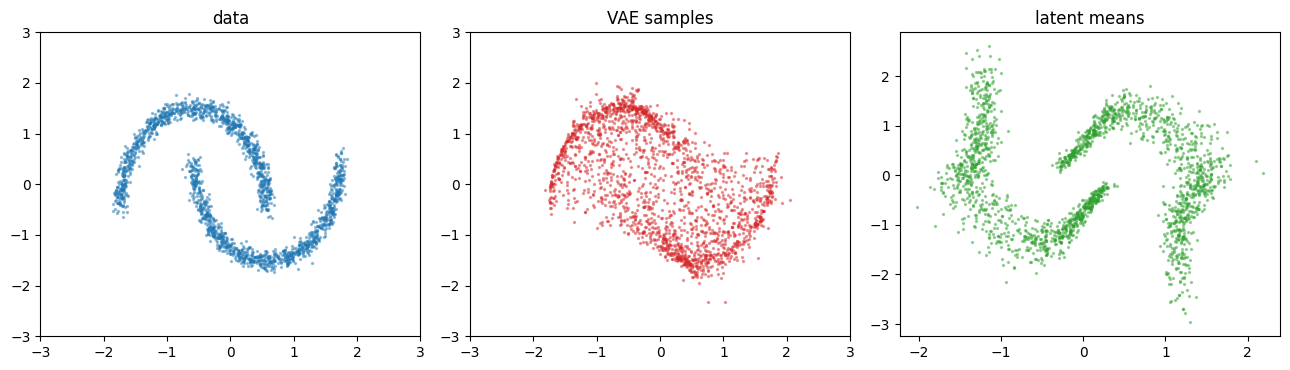

In [3]:
with torch.no_grad():
    gen = decoder(torch.randn(2000, latent))
    mu, _ = encoder(data).chunk(2, dim=1)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
show = torch.randperm(len(data))[:2000]
axes[0].scatter(data[show, 0], data[show, 1], s=2, alpha=0.4)
axes[0].set_title("data")
axes[1].scatter(gen[:, 0], gen[:, 1], s=2, alpha=0.4, color="tab:red")
axes[1].set_title("VAE samples")
axes[2].scatter(mu[show, 0], mu[show, 1], s=2, alpha=0.4, color="tab:green")
axes[2].set_title("latent means")
for ax in axes[:2]:
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
plt.tight_layout(); plt.show()